# Heat-Pump Hypothesis Tests

Two hypotheses tested on the **same synthetic-substation data** as
`HeatPumpDetection_clean.ipynb` (loaded from `data/substations_data.pkl`):

1. **The aggregated simultaneity factor increases linearly with decreasing
   temperature.** The whole fleet's coincident HP load is divided by the total
   installed capacity (`SF = ΣHP_Load / ΣHP_Peak`) and regressed on the national
   mean temperature; a linear fit is compared against a hockey-stick fit.
2. **The R² of a hockey-stick fit of net load vs mean temperature decreases at
   higher temporal resolution.** Per-substation hockey-stick fits are repeated at
   15 min, 1 h, 8 h and daily resolution and their R² distributions compared.

## Imports and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from scipy.optimize import curve_fit
from scipy.stats import linregress
from tqdm import tqdm


In [2]:
# Same data as HeatPumpDetection_clean.ipynb
substations_df = pickle.load(open('data/substations_data.pkl', 'rb'))
substations_df = substations_df.fillna(0)
print('substations:', len(substations_df))
print('columns:', list(substations_df.columns))


substations: 2000
columns: ['size', 'HP_ratio', 'weather_id', 'households_hp', 'households', 'HP_Load', 'Total_Load', 'Temperature', 'HP_Peak']


In [3]:
# ---------------------------------------------------------------------------
# Hockey-stick model (identical to the one in HeatPumpDetection_clean.ipynb):
#     y(T) = base + slope * max(0, T_balance - T)
# ---------------------------------------------------------------------------
T_BALANCE_BOUNDS = (8, 20)   # degC, plausible balance/threshold-temperature range


def hockey_stick(T, base, slope, T_balance):
    return base + slope * np.maximum(0, T_balance - T)


def fit_hockey_stick(x, y, T_balance_bounds=T_BALANCE_BOUNDS):
    """Fit the 3-parameter hockey-stick curve; return (base, slope, T_balance, r2)."""
    p0 = [np.median(y), 0.5, np.mean(T_balance_bounds)]
    bounds = ([0, 0, T_balance_bounds[0]], [np.inf, np.inf, T_balance_bounds[1]])
    popt, _ = curve_fit(hockey_stick, x, y, p0=p0, bounds=bounds, maxfev=5000)
    y_pred = hockey_stick(x, *popt)
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0.0
    base, slope, T_balance = popt
    return base, slope, T_balance, r2


## Hypothesis 1 — aggregated simultaneity factor vs temperature

The fleet is aggregated across all substations with heat pumps:
`SF(day) = Σ_s HP_Load_s / Σ_s HP_Peak_s` (daily-mean coincident HP power over
total installed capacity), plotted against the daily national mean temperature
`T = mean_s Temperature_s`. A linear fit (full range and heating-regime only) is
compared with a hockey-stick fit to judge whether the rise is genuinely linear.

In [4]:
# Build daily fleet aggregates
daily_hp_load = {}
daily_temp = {}
for sid in tqdm(substations_df.index, desc='Aggregating fleet'):
    hp_peak = substations_df.loc[sid, 'HP_Peak']
    if hp_peak <= 0:
        continue
    hp_load = substations_df.loc[sid, 'HP_Load']
    temp = substations_df.loc[sid, 'Temperature']
    if not isinstance(hp_load, pd.Series) or not isinstance(temp, pd.Series):
        continue
    daily_hp_load[sid] = hp_load.resample('D').mean()
    daily_temp[sid] = temp.resample('D').mean()

load_df = pd.DataFrame(daily_hp_load)
temp_df = pd.DataFrame(daily_temp)
fleet_hp_peak = substations_df.loc[load_df.columns, 'HP_Peak'].sum()

fleet = pd.DataFrame({
    'Temp': temp_df.mean(axis=1),                 # national mean temperature
    'SF': load_df.sum(axis=1) / fleet_hp_peak,    # aggregated simultaneity factor
}).dropna()
x, y = fleet['Temp'].values, fleet['SF'].values
print(f'{len(fleet)} daily fleet points | fleet HP_Peak = {fleet_hp_peak:.0f} kW')


Aggregating fleet: 100%|██████████| 2000/2000 [00:04<00:00, 458.09it/s]


365 daily fleet points | fleet HP_Peak = 457044 kW


Linear (full range): SF = -0.01127*T + 0.2434  |  R² = 0.928, slope p = 2.45e-209
Hockey-stick: base=0.0278, slope=0.01459/°C, T_threshold=16.1°C, R² = 0.979
Linear (T < 16.1°C, n=245): R² = 0.960, slope = -0.01459, p = 3.28e-172


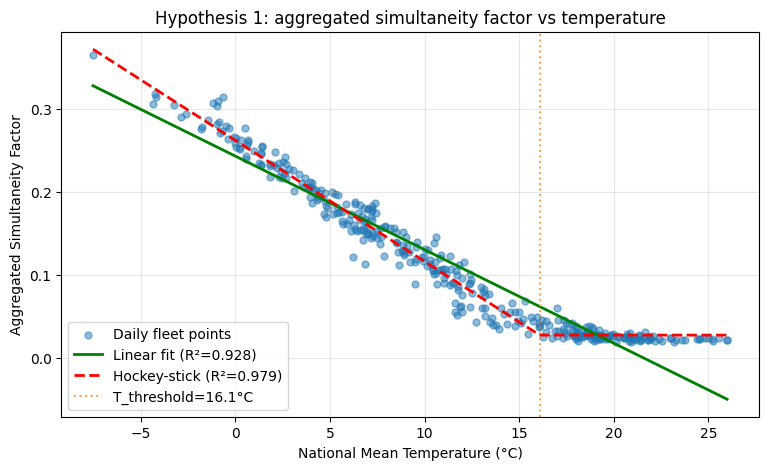

In [5]:
# Linear fit over the full range
lr = linregress(x, y)
print(f'Linear (full range): SF = {lr.slope:.5f}*T + {lr.intercept:.4f}  |  '
      f'R² = {lr.rvalue**2:.3f}, slope p = {lr.pvalue:.2e}')

# Hockey-stick fit (captures a possible warm plateau -> tests linearity)
base, slope_hs, t_thr, r2_hs = fit_hockey_stick(x, y, T_BALANCE_BOUNDS)
print(f'Hockey-stick: base={base:.4f}, slope={slope_hs:.5f}/°C, '
      f'T_threshold={t_thr:.1f}°C, R² = {r2_hs:.3f}')

# Linear fit restricted to the heating regime (below the threshold)
heat = fleet[fleet['Temp'] < t_thr]
lr_heat = linregress(heat['Temp'].values, heat['SF'].values)
print(f'Linear (T < {t_thr:.1f}°C, n={len(heat)}): R² = {lr_heat.rvalue**2:.3f}, '
      f'slope = {lr_heat.slope:.5f}, p = {lr_heat.pvalue:.2e}')

# Plot
xs = np.linspace(x.min(), x.max(), 200)
plt.figure(figsize=(9, 5))
plt.scatter(x, y, s=25, alpha=0.5, label='Daily fleet points')
plt.plot(xs, lr.intercept + lr.slope * xs, color='green', lw=2,
         label=f'Linear fit (R²={lr.rvalue**2:.3f})')
plt.plot(xs, hockey_stick(xs, base, slope_hs, t_thr), color='red', lw=2, ls='--',
         label=f'Hockey-stick (R²={r2_hs:.3f})')
plt.axvline(t_thr, color='tab:orange', ls=':', alpha=0.7, label=f'T_threshold={t_thr:.1f}°C')
plt.xlabel('National Mean Temperature (°C)')
plt.ylabel('Aggregated Simultaneity Factor')
plt.title('Hypothesis 1: aggregated simultaneity factor vs temperature')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


## Hypothesis 2 — fit R² vs temporal resolution

For each substation the net load (`Total_Load`) and temperature are resampled
to 15 min / 1 h / 8 h / daily means, a hockey-stick curve `Load(T)` is fitted at
each resolution, and the R² is recorded. If the hypothesis holds, the R²
distribution should rise as the resolution gets coarser (15 min → daily).
A random subset of substations is used to keep the 15-min fits tractable.

In [6]:
RESOLUTIONS = [('15min', '15 min'), ('1h', '1 hour'), ('8h', '8 hours'), ('D', 'daily')]

# subsample substations with heat pumps (15-min fits over the full fleet are heavy)
rng = np.random.default_rng(42)
sub_ids = substations_df.index[substations_df['HP_Peak'] > 0].to_numpy()
if len(sub_ids) > 150:
    sub_ids = rng.choice(sub_ids, size=150, replace=False)

res_r2 = {label: [] for _, label in RESOLUTIONS}
for sid in tqdm(sub_ids, desc='Resolution sweep'):
    total = substations_df.loc[sid, 'Total_Load']
    temp = substations_df.loc[sid, 'Temperature']
    if not isinstance(total, pd.Series) or not isinstance(temp, pd.Series):
        continue
    for rule, label in RESOLUTIONS:
        t = temp.resample(rule).mean()
        l = total.resample(rule).mean()
        d = pd.DataFrame({'T': t, 'L': l}).dropna()
        if len(d) < 30:
            continue
        try:
            _, _, _, r2 = fit_hockey_stick(d['T'].values, d['L'].values, T_BALANCE_BOUNDS)
            res_r2[label].append(r2)
        except Exception:
            continue


Resolution sweep: 100%|██████████| 150/150 [00:09<00:00, 15.35it/s]


Resolution  n_fits  Mean_R2  Median_R2
    15 min     150 0.438742   0.484878
    1 hour     150 0.500565   0.565507
   8 hours     150 0.698482   0.783871
     daily     150 0.838698   0.905696


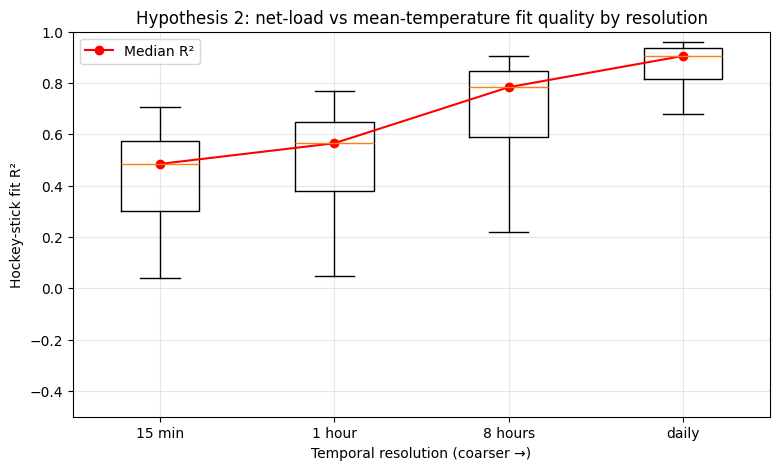

In [7]:
labels = [label for _, label in RESOLUTIONS]
data = [res_r2[l] for l in labels]

summary = pd.DataFrame({
    'Resolution': labels,
    'n_fits': [len(d) for d in data],
    'Mean_R2': [np.mean(d) if d else np.nan for d in data],
    'Median_R2': [np.median(d) if d else np.nan for d in data],
})
print(summary.to_string(index=False))

medians = [np.median(d) if d else np.nan for d in data]
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(data, labels=labels, showfliers=False)
ax.plot(range(1, len(labels) + 1), medians, 'o-', color='red', label='Median R²')
ax.set_xlabel('Temporal resolution (coarser →)')
ax.set_ylabel('Hockey-stick fit R²')
ax.set_ylim(-0.5, 1.0)
ax.set_title('Hypothesis 2: net-load vs mean-temperature fit quality by resolution')
ax.grid(alpha=0.3)
ax.legend()
plt.show()
